In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import r2_score
warnings.filterwarnings('ignore')


# 设置全局绘图风格（Nature期刊级别）
sns.set_palette("RdBu_r")
sns.set_style("whitegrid", {'grid.linestyle': '--', 'axes.edgecolor': '0.3'})
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'figure.dpi': 600,
    'savefig.dpi': 600,
    'savefig.format': 'jpeg'
})

# 读取数据
data = pd.read_csv("01_All_data.csv")
X = data.drop(columns=["n"])
y = data["n"]

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# 训练模型
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)

d:\LenovoSoftstore\Install\Anaconda\envs\cmip\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=16,
             num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

In [2]:
# 使用模型对训练集和测试集进行预测
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)
# 计算评价指标RMSE、R²
# RMSE
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
rmse_train = rmse(y_train, y_train_pred)
rmse_test = rmse(y_test, y_test_pred)

# NSE
def NSE(y_pred, y_true):
    ave_obs = sum(y_true)/len(y_true)
    Numerator = sum((y_true-y_pred)**2)
    Denominator = sum((y_true-ave_obs)**2)
    return 1 -Numerator/Denominator
nse_train = NSE(y_train, y_train_pred)
nse_test = NSE(y_test, y_test_pred)

# R² (决定系数)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("训练集评价:")
print(f"RMSE: {rmse_train:.4f}, R²: {r2_train:.4f}, NSE: {nse_train:.4f}")
print("测试集评价:")
print(f"RMSE: {rmse_test:.4f}, R²: {r2_test:.4f}, NSE: {nse_test:.4f}")

训练集评价:
RMSE: 0.2352, R²: 0.8983, NSE: 0.8784
测试集评价:
RMSE: 0.2784, R²: 0.8559, NSE: 0.8245


In [3]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

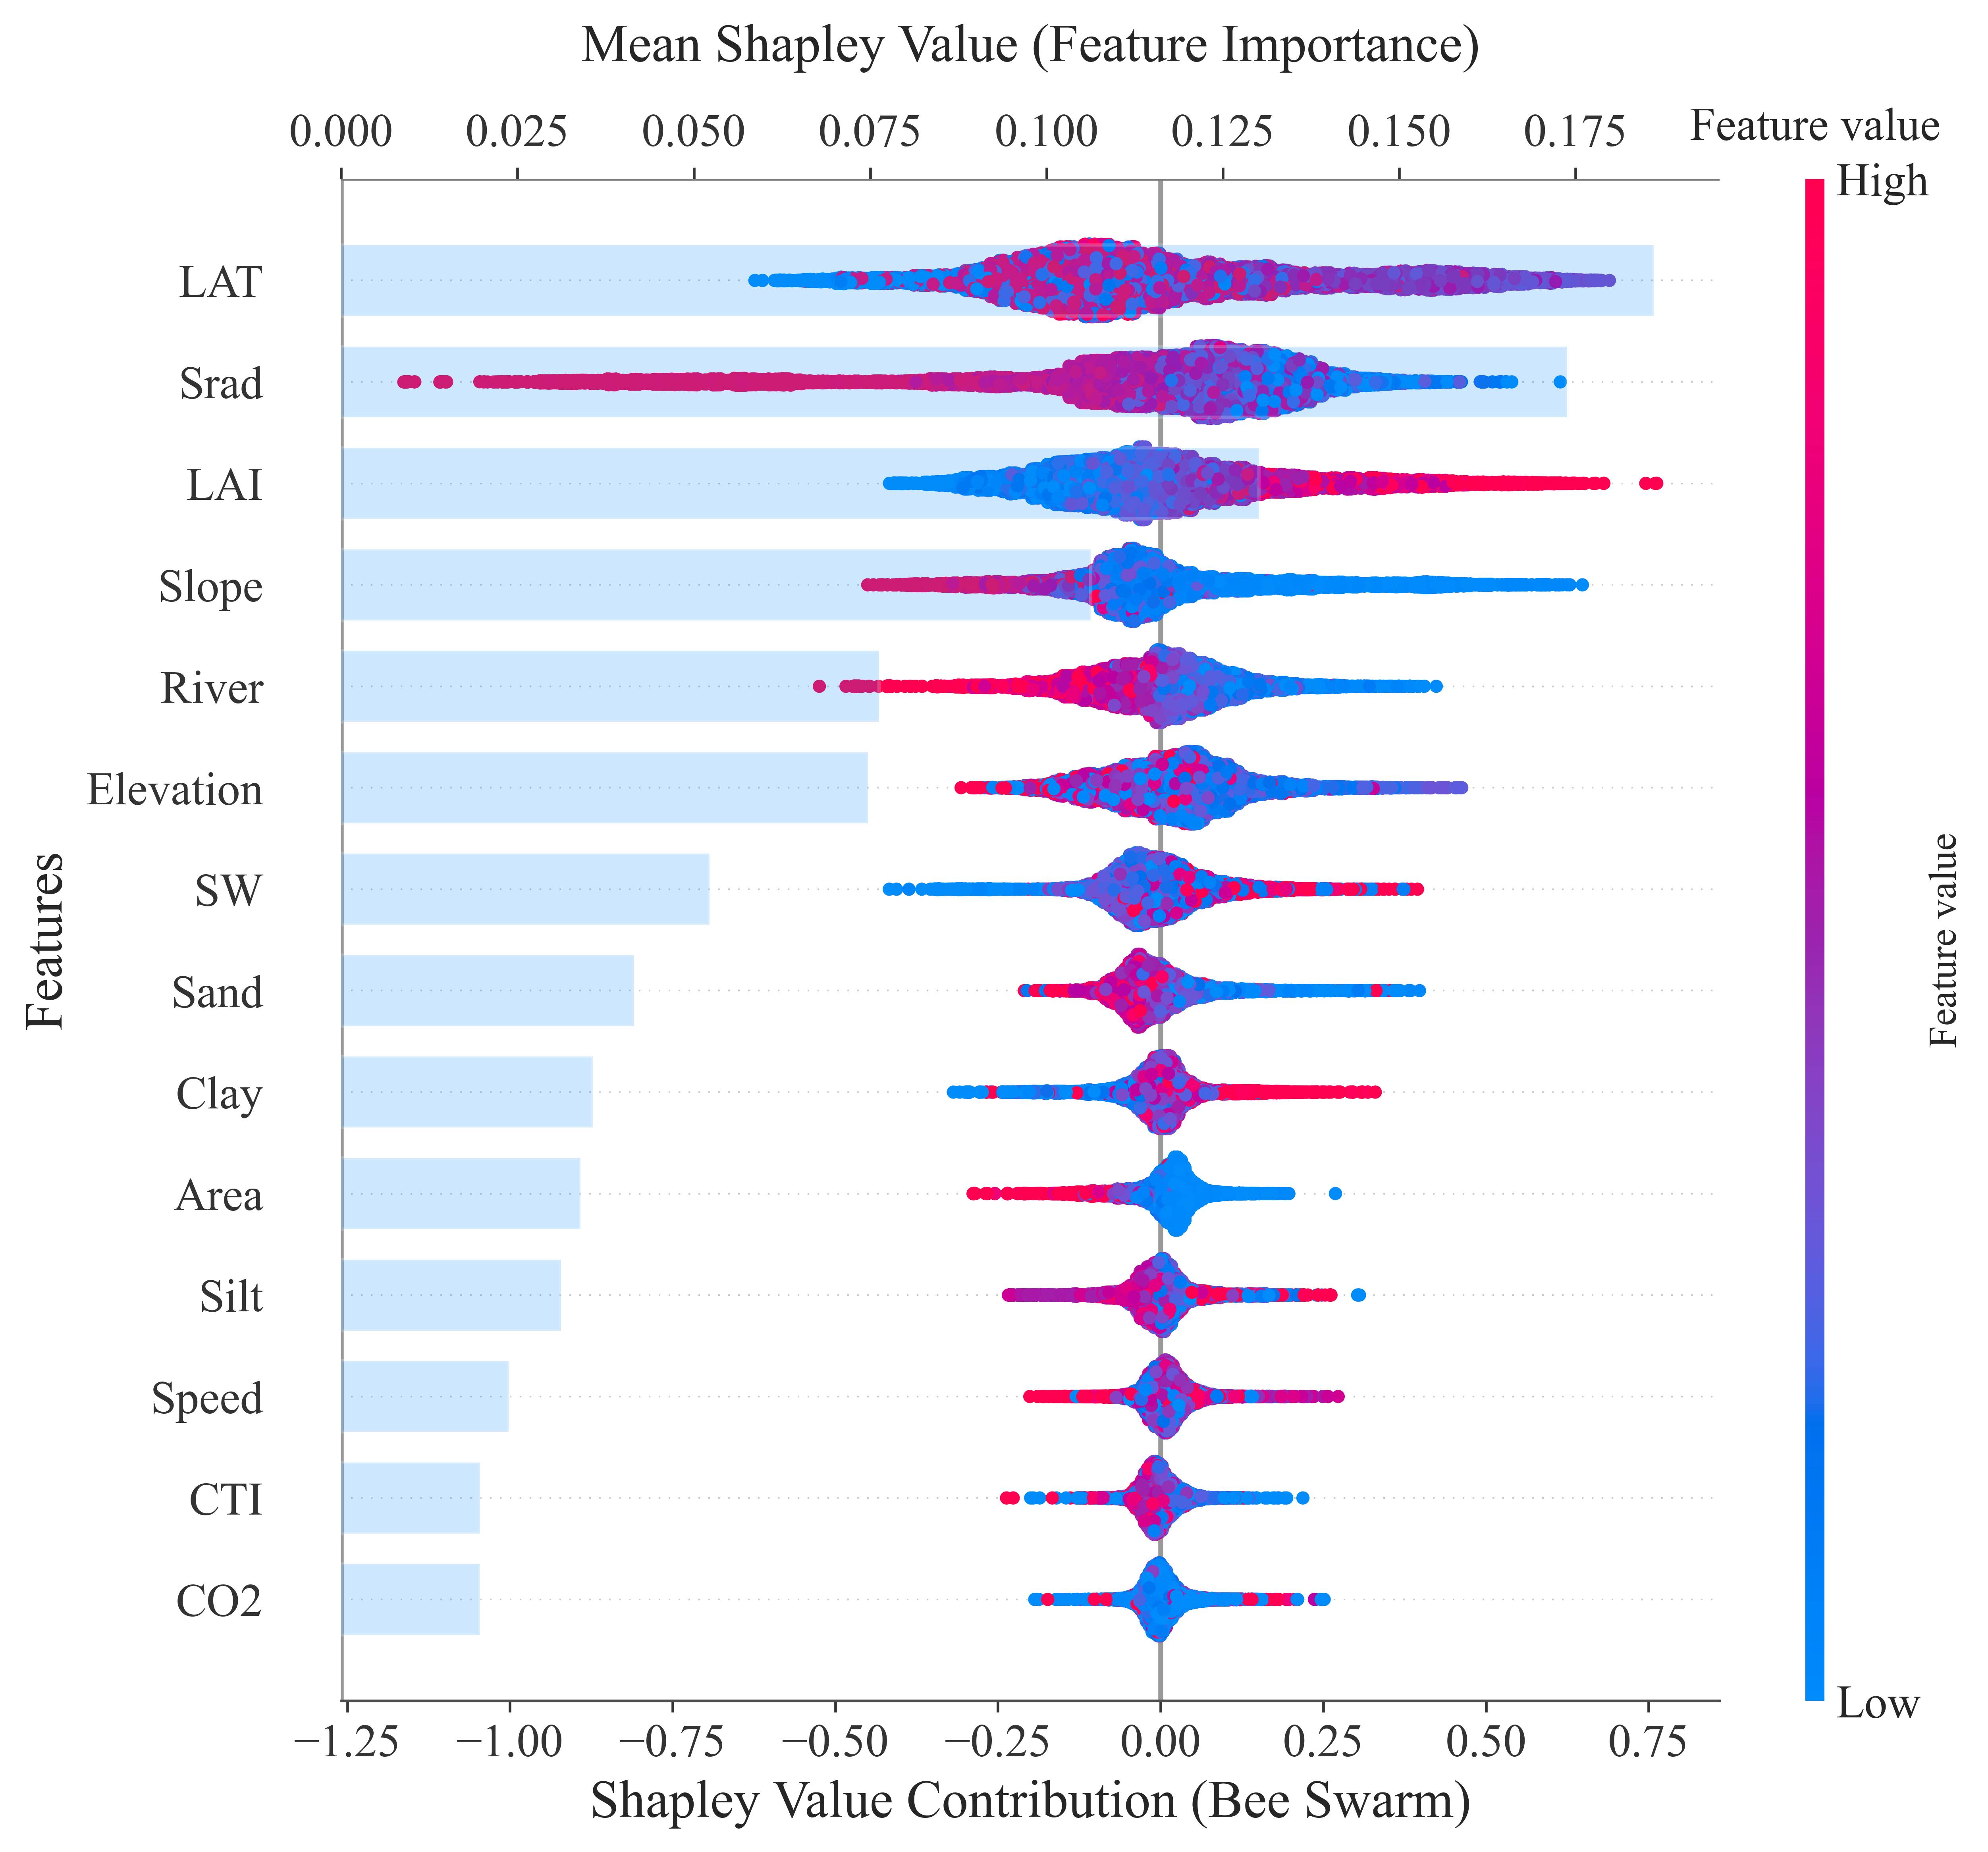

In [4]:
# ====== 绘制图形 ======
#重要性排序叠加蜂群图
fig, ax1 = plt.subplots(figsize=(10, 8), dpi=600)

# 绘制 SHAP 蜂群图（带色柱）
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns,
    plot_type="dot",
    #cmap='RdYlGn',
    show=False,
    color_bar=True
)

# 调整主图位置（右侧留出色条空间）
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])
ax1 = plt.gca()

# ====== 调整色柱样式 ======
# 获取当前 figure 中的 colorbar 对象
fig = plt.gcf()
cbar = fig.axes[-1]  # SHAP 会自动在最后一个 axes 中放 colorbar

# 调整色柱位置和大小（[left, bottom, width, height]）
cbar.set_position([0.88, 0.2, 0.03, 0.65])  # 可调节宽度 (0.03) 与位置 (0.88)

# 修改色柱刻度和标签字号
cbar.tick_params(labelsize=14)

# 修改色柱标题字体
cbar.set_title('Feature value', fontsize=14, pad=12)

# ====== 创建共享 y 轴的顶部 x 轴 ======
ax2 = ax1.twiny()

# 绘制透明的特征重要性条形图（叠加在顶部）
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # 对齐蜂群图位置

# ====== 在顶部添加参考线（可选） ======
ax2.axhline(y=14, color='gray', linestyle='-', linewidth=1)

# 设置条形透明度
bars = ax2.patches
for bar in bars:
    bar.set_alpha(0.2)

# ====== 坐标轴与标签设置 ======
ax1.set_xlabel('Shapley Value Contribution (Bee Swarm)', fontsize=16)
ax2.set_xlabel('Mean Shapley Value (Feature Importance)', fontsize=16, labelpad=16)
ax2.xaxis.set_label_position('top')  # 顶部标签放到上方
ax2.xaxis.tick_top()                 # 顶部刻度
ax1.set_ylabel('Features', fontsize=16)

# 坐标刻度字号
ax1.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='x', labelsize=14)

# 自动布局
plt.tight_layout()
ax1.grid(False)
ax2.grid(False)
# 显示图像
plt.show()


In [ ]:
#带有趋势线的SHAP主效应和交互效应图的设置
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
import numpy as np

def add_polynomial_trendline_with_ci(x, y, ax, n_bootstrap=100, ci_color='lightblue'):
    sort_idx = np.argsort(x)
    x_sorted, y_sorted = x[sort_idx], y[sort_idx]
    x_trend = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
    bootstrap_predictions = []

    # Bootstrap采样
    for _ in range(n_bootstrap):
        idx = resample(range(len(x_sorted)), replace=True)
        x_res, y_res = x_sorted[idx], y_sorted[idx]
        model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                          ('linear', LinearRegression())])
        model.fit(x_res.reshape(-1, 1), y_res)
        bootstrap_predictions.append(model.predict(x_trend))
    
    bootstrap_predictions = np.array(bootstrap_predictions)
    lower = np.percentile(bootstrap_predictions, 2.5, axis=0)
    upper = np.percentile(bootstrap_predictions, 97.5, axis=0)

    # 最终趋势线
    model_final = Pipeline([('poly', PolynomialFeatures(degree=3)),
                            ('linear', LinearRegression())])
    model_final.fit(x_sorted.reshape(-1, 1), y_sorted)
    y_trend = model_final.predict(x_trend)
    
    ax.fill_between(x_trend.ravel(), lower, upper, color=ci_color, alpha=0.4, label='95% CI')
    ax.plot(x_trend, y_trend, color='darkblue', linewidth=2, label='Trend Line')
    ax.legend(loc='best', fontsize=20)

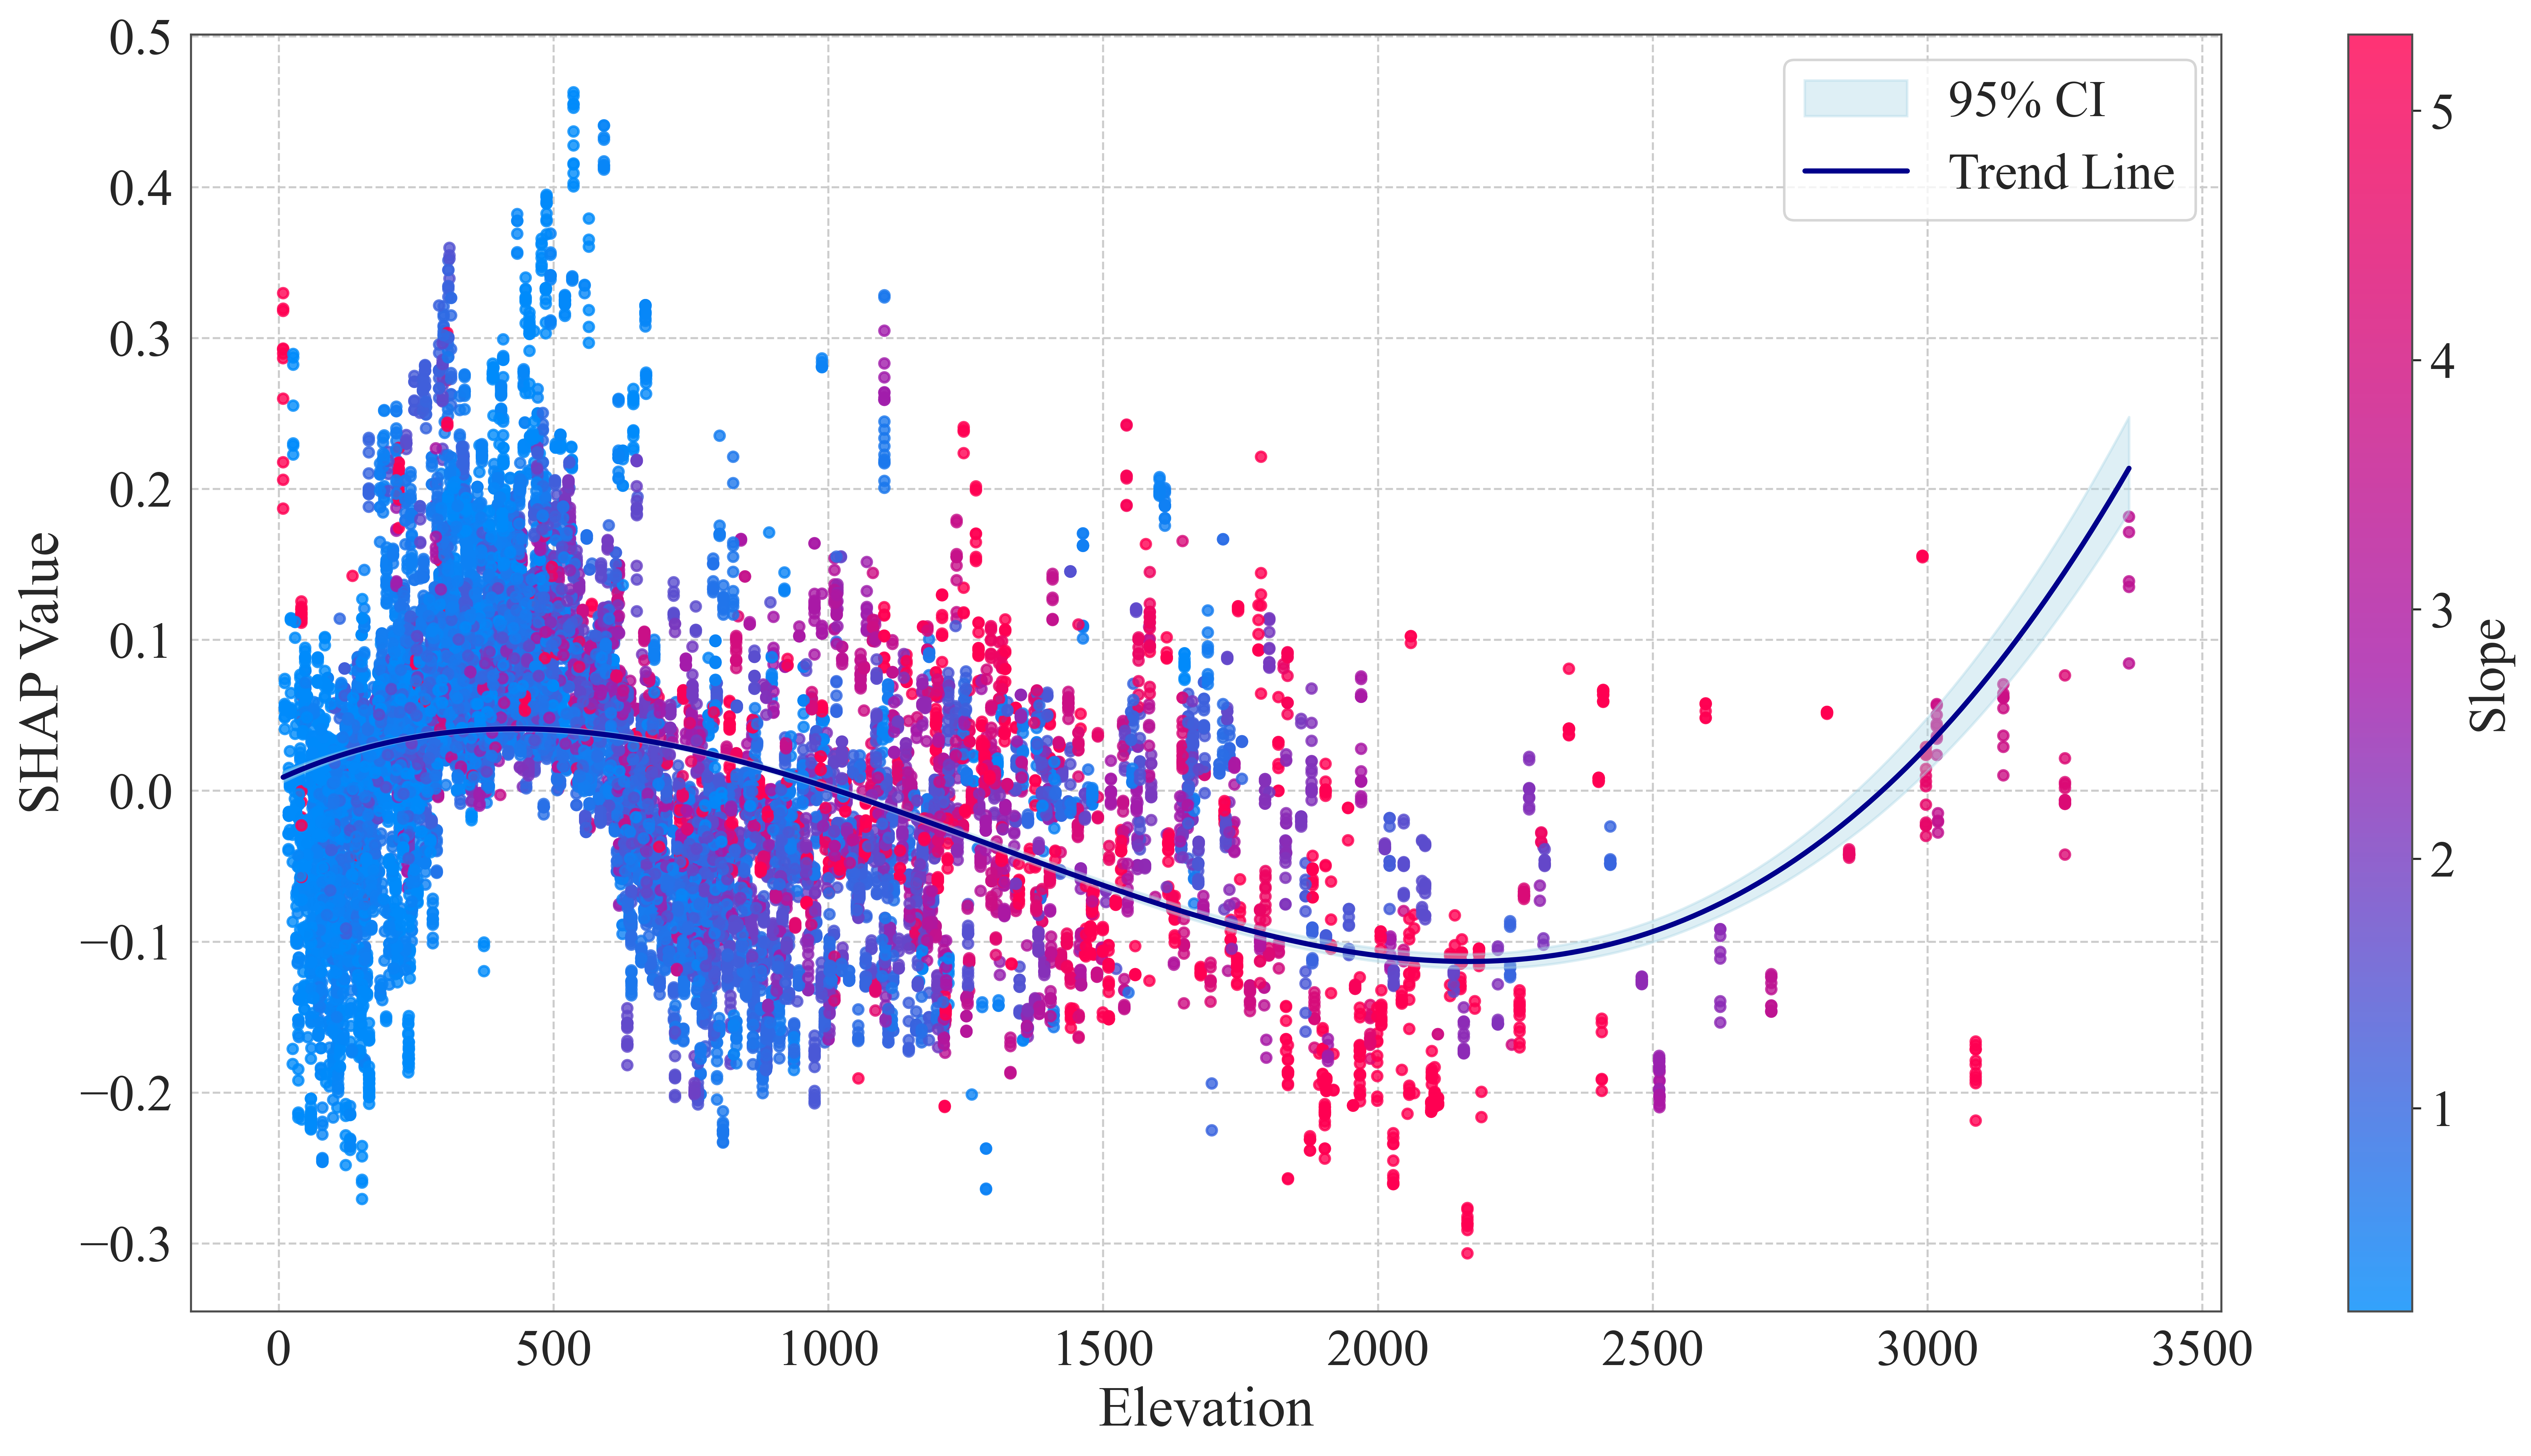

In [8]:
#绘制主效应或交互效应SHAP图
from matplotlib.colors import LinearSegmentedColormap
#自定义颜色柱
shap_cmap = LinearSegmentedColormap.from_list(
    'shap_default',
    [
        (0.0, '#008BFB'),  # 深蓝（low）#008BFB
        (0.5, '#A61AA9'),
        (1.0, '#FF0052')   # 深红（high）#FF0052
    ]
)


def plot_feature_interaction(shap_values, features, feature_names, feature1_index, feature2_index, ci_color='lightblue'):
    fig, ax = plt.subplots(figsize=(15, 8))


    
    feature1_name = feature_names[feature1_index]
    feature2_name = feature_names[feature2_index]
    
    x = features[:, feature1_index]
    y = shap_values.values[:, feature1_index]
    color_values = features[:, feature2_index]
    
    #特征显示范围（下面是显示5%~95%的数据）
    vmin = np.percentile(color_values, 5)
    vmax = np.percentile(color_values, 95)
    scatter = ax.scatter(x, y, c=color_values, cmap=shap_cmap,vmin=vmin, vmax=vmax, alpha=0.8, s=15)
    add_polynomial_trendline_with_ci(x, y, ax, ci_color=ci_color)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(f'{feature2_name}', fontsize=20)
    
    # 设置色柱刻度字号为20
    cbar.ax.tick_params(labelsize=20)
    
    ax.set_xlabel(feature1_name, fontsize=22)
    ax.set_ylabel('SHAP Value', fontsize=22)
    
    # 设置坐标轴刻度字号
    ax.tick_params(axis='both', which='major', labelsize=20)
    #ax.grid(False)

    plt.tight_layout()
    plt.show()

#绘制主效应或交互效应SHAP图，两个数字代表第n-1个变量（0代表第一个变量）
# 若两个数字相等，则表示主效应
plot_feature_interaction(shap_values, X_test.values, X_test.columns.tolist(), 4, 3, ci_color='lightblue')